# şimdi burda finetuned.pth modelini yükleyip imageda denedim

In [14]:
import os
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.datasets import CocoDetection
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.ops import nms
from torch.utils.data import DataLoader
from torchvision import transforms

# --- AYARLAR ---
BASE_PATH = r"C:\Users\LENOVO\Downloads\GP Object detection.v1i.coco"
NUM_CLASSES = 21  # 20 kategori + 1 arka plan
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
IMG_SIZE = 224    # Roboflow'un resize boyutu

class RoboflowPipelineDataset(CocoDetection):
    def __init__(self, root, annFile, transform=None):
        super().__init__(root, annFile)
        self._transform = transform

    def __getitem__(self, idx):
        img, target = super().__getitem__(idx)
        image_id = self.ids[idx]
        boxes, labels = [], []
        
        for obj in target:
            x, y, w, h = obj['bbox']
            if w <= 0 or h <= 0: continue
            boxes.append([x, y, x + w, y + h])
            labels.append(obj['category_id'] + 1) # Arka plan 0 olduğu için +1

        target_dict = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([image_id]),
            "area": torch.as_tensor([(b[2]-b[0])*(b[3]-b[1]) for b in boxes], dtype=torch.float32) if boxes else torch.tensor([0]),
            "iscrowd": torch.zeros((len(labels),), dtype=torch.int64)
        }
        if self._transform: img = self._transform(img)
        return img, target_dict

def collate_fn(batch): return tuple(zip(*batch))

In [15]:
def build_pipeline_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model.to(DEVICE)

def train_pipeline(model, loader, epochs=10, lr=0.005):
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=0.0005)
    model.train()
    
    for epoch in range(epochs):
        total_loss = 0
        for images, targets in loader:
            images = list(img.to(DEVICE) for img in images)
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            total_loss += losses.item()
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(loader):.4f}")
    torch.save(model.state_dict(), "final_pipeline_model.pth")

In [16]:
def run_inference(image_path, model, score_thresh=0.3):
    model.eval()
    orig_img = Image.open(image_path).convert("RGB")
    w_orig, h_orig = orig_img.size
    
    # 1. Eğitimdeki gibi hazırla
    test_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = test_transform(orig_img).to(DEVICE).unsqueeze(0)
    
    with torch.no_grad():
        prediction = model(input_tensor)
    
    # 2. Kutuları orijinal boyuta ölçekle
    boxes = prediction[0]['boxes']
    scores = prediction[0]['scores']
    labels = prediction[0]['labels']
    
    boxes[:, [0, 2]] *= (w_orig / IMG_SIZE)
    boxes[:, [1, 3]] *= (h_orig / IMG_SIZE)
    
    # 3. NMS (Üst üste binmeyi engelle)
    keep = nms(boxes, scores, iou_threshold=0.3) # 0.2 yapınca 3 tane bounding box oluştu 0.1 yapınca iki tane. en iyisi bu gibi yemeklerin doğal konumundan kaynaklı üst üste biniyolar.
    
    img_cv = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    for i in keep:
        if scores[i] > score_thresh:
            b = boxes[i].cpu().numpy()
            cv2.rectangle(img_cv, (int(b[0]), int(b[1])), (int(b[2]), int(b[3])), (0, 255, 0), 2)
            cv2.putText(img_cv, f"ID:{labels[i]-1} {scores[i]:.2f}", (int(b[0]), int(b[1]-5)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    plt.imshow(img_cv); plt.axis('off'); plt.show()

In [17]:
# --- MODELİ YÜKLEME ---
def load_previous_model(path, num_classes):
    # Dünkü mimarinin aynısını kuruyoruz
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    # Kaydedilen ağırlıkları yüklüyoruz
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        print(f"Model başarıyla yüklendi: {path}")
    else:
        print("Hata: Belirtilen model dosyası bulunamadı!")
    
    return model.to(DEVICE)

# Kullanım:
# my_model = load_previous_model("gp_food_model_v2.pth", 21)

# sonuç bu alltaki resim çıktı düzgün yani

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Model başarıyla yüklendi: gp_food_model_finetuned.pth


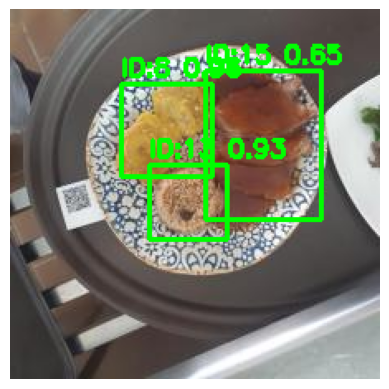

In [18]:
# 1. Veri setini ve Loader'ı yeni pipeline kurallarına göre hazırla
train_ds = RoboflowPipelineDataset(
    os.path.join(BASE_PATH, "train"), 
    os.path.join(BASE_PATH, "train", "_annotations.coco.json"), 
    transform=transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, collate_fn=collate_fn)

# 2. Dünkü modeli yükle
MODEL_PATH = "gp_food_model_finetuned.pth" # Dünkü dosya adın
my_model = load_previous_model(MODEL_PATH, 21)

# 3. İSTEĞE BAĞLI: Eğitime devam et
# train_pipeline(my_model, train_loader, epochs=5, lr=0.001)

# 4. Tahmin Pipeline'ını çalıştır (Yeni NMS ve Scale ayarlarıyla)
run_inference(r"C:\Users\LENOVO\Desktop\Deep\GP Object detection.v1i.coco\test\20240220_123350_jpg.rf.27368f5318fb14cbc636c7543ef7a993.jpg", my_model, score_thresh=0.4)
    #r"C:\Users\LENOVO\Desktop\Deep\GP Object detection.v1i.coco\test\02-mp4_frame_0_jpg.rf.eb697cd2a3718cc50083e27c90343165.jpg", my_model, score_thresh=0.4)

# burda manuel kalori ekleyip hesaplattım. farklı bir resimde

Başarılı: Fine-tuned model yüklendi.

--- DEEPDIET ANALİZ SONUCU ---
Tespit: Papa | Güven: %98.1 | Kalori: 115 kcal
Tespit: Arroz | Güven: %96.3 | Kalori: 195 kcal
Tespit: Carne res | Güven: %94.9 | Kalori: 375 kcal
Tespit: Ensalada | Güven: %90.0 | Kalori: 60 kcal


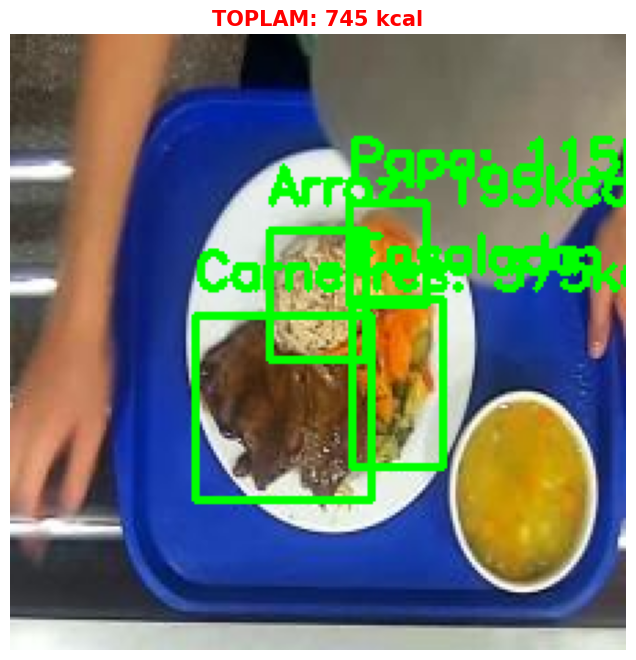

In [19]:
import os
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.ops import nms
from torchvision import transforms

# --- 1. AYARLAR VE KATEGORİ HARİTASI ---
# Roboflow'dan gelen 'id' değerlerini isimlere bağlıyoruz
# Dikkat: Model çıktı verirken 1-21 arası ID verir. 
# Bu sözlük, o ID'leri senin gerçek yemek isimlerine bağlar.
FOOD_MAP = {
    1: "food", 2: "Aguacate", 12: "Ahuyama", 13: "Arepa", 14: "Arroz", 
    15: "Arroz con Pollo", 16: "Carne res", 17: "Chicharron", 18: "Chorizo", 19: "Criolla", 
    20: "Ensalada", 3: "Frijol", 4: "Habichuela", 5: "Huevo", 6: "Lentejas", 
    7: "Morcilla", 8: "Papa", 9: "Platano", 10: "Pollo", 11: "QR", 21: "Trucha"
}

# 100 gram için kcal değerleri
KCAL_MAP = {
    "Aguacate": 160, "Ahuyama": 26, "Arepa": 250, "Arroz": 130,
    "Arroz con Pollo": 150, "Carne res": 250, "Chicharron": 540,
    "Chorizo": 450, "Criolla": 80, "Ensalada": 40, "Frijol": 140,
    "Habichuela": 31, "Huevo": 155, "Lentejas": 116, "Morcilla": 380,
    "Papa": 77, "Platano": 120, "Pollo": 165, "Trucha": 150, "food": 100
}

DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
MODEL_PATH = "gp_food_model_finetuned.pth"
IMG_SIZE = 224 

# --- 2. MODEL YÜKLEME ---
def load_final_model(path, num_classes=22): # Background + 21 Sınıf = 22
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        model.to(DEVICE).eval()
        print(f"Başarılı: Fine-tuned model yüklendi.")
    else:
        raise FileNotFoundError(f"HATA: {path} bulunamadı!")
    return model

# --- 3. INFERENCE VE KALORİ ANALİZİ ---
def run_food_ai(image_path, model, score_thresh=0.5, nms_thresh=0.2):
    orig_img = Image.open(image_path).convert("RGB")
    w_orig, h_orig = orig_img.size
    
    test_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = test_transform(orig_img).to(DEVICE).unsqueeze(0)
    
    with torch.no_grad():
        prediction = model(input_tensor)
    
    boxes = prediction[0]['boxes']
    scores = prediction[0]['scores']
    labels = prediction[0]['labels']
    
    # Boyutları geri ölçekleme
    boxes[:, [0, 2]] *= (w_orig / IMG_SIZE)
    boxes[:, [1, 3]] *= (h_orig / IMG_SIZE)
    
    # NMS ile çakışmaları temizle
    keep = nms(boxes, scores, nms_thresh)
    final_boxes, final_scores, final_labels = boxes[keep], scores[keep], labels[keep]
    
    img_cv = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    total_kcal = 0
    
    print("\n--- DEEPDIET ANALİZ SONUCU ---")
    for i in range(len(final_scores)):
        if final_scores[i] > score_thresh:
            b = final_boxes[i].cpu().numpy()
            label_id = final_labels[i].item()
            
            # Sözlükten ismi bul
            name = FOOD_MAP.get(label_id, "Bilinmeyen Yemek")
            kcal_per_100g = KCAL_MAP.get(name, 100)
            
            # Alan bazlı basit porsiyon tahmini (Geliştirilebilir)
            # Burada her tespiti ortalama 150gr varsayıyoruz
            estimated_weight = 150 
            item_kcal = int((kcal_per_100g * estimated_weight) / 100)
            total_kcal += item_kcal
            
            print(f"Tespit: {name} | Güven: %{final_scores[i]*100:.1f} | Kalori: {item_kcal} kcal")
            
            # Çizim
            cv2.rectangle(img_cv, (int(b[0]), int(b[1])), (int(b[2]), int(b[3])), (0, 255, 0), 2)
            cv2.putText(img_cv, f"{name}: {item_kcal}kcal", (int(b[0]), int(b[1]-10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    plt.figure(figsize=(10, 8))
    plt.imshow(img_cv)
    plt.title(f"TOPLAM: {total_kcal} kcal", fontsize=15, color='red', fontweight='bold')
    plt.axis('off')
    plt.show()

# --- 4. BAŞLAT ---
if __name__ == "__main__":
    # Toplam 21 yemek + 1 arka plan = 22 num_classes
    my_model = load_final_model(MODEL_PATH, num_classes=21) 
    
    test_image = r"C:\Users\LENOVO\Desktop\Deep\GP Object detection.v1i.coco\test\02-mp4_frame_0_jpg.rf.eb697cd2a3718cc50083e27c90343165.jpg"
    
    if os.path.exists(test_image):
        run_food_ai(test_image, my_model)
    else:
        print("HATA: Test resmi belirtilen yolda bulunamadı.")

# burda density area based oalrak hesaplayığ kalori belirledi.


--- DEEPDIET 4. HAFTA ANALİZ SONUCU ---
Tespit: Papa            | Yoğunluk: 0.90 | Kalori: 16 kcal
Tespit: Arroz           | Yoğunluk: 1.30 | Kalori: 62 kcal
Tespit: Carne res       | Yoğunluk: 1.30 | Kalori: 305 kcal
Tespit: Ensalada        | Yoğunluk: 1.30 | Kalori: 23 kcal


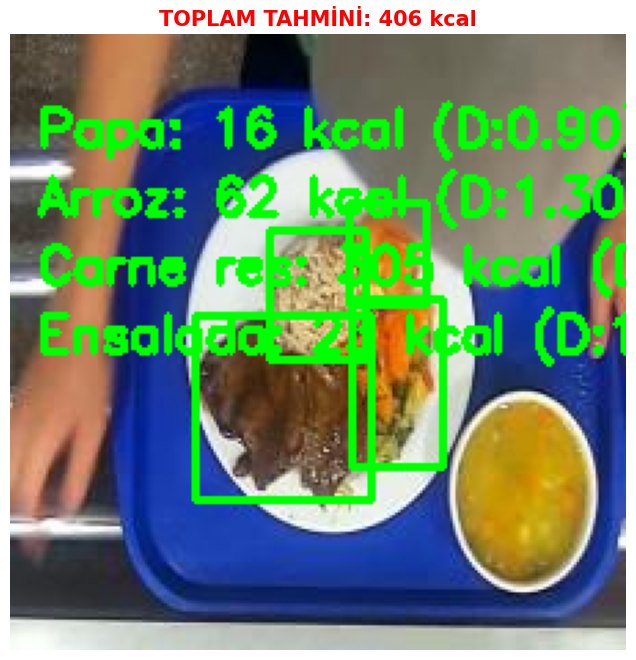

In [20]:
import os
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.ops import nms
from torchvision import transforms

# --- 1. AYARLAR VE KATEGORİ HARİTASI ---
# Modelinin 21 sınıf (bg + 20 yemek) olarak eğitildiği doğrulandı.
FOOD_MAP = {
    1: "food", 2: "Aguacate", 12: "Ahuyama", 13: "Arepa", 14: "Arroz", 
    15: "Arroz con Pollo", 16: "Carne res", 17: "Chicharron", 18: "Chorizo", 19: "Criolla", 
    20: "Ensalada", 3: "Frijol", 4: "Habichuela", 5: "Huevo", 6: "Lentejas", 
    7: "Morcilla", 8: "Papa", 9: "Platano", 10: "Pollo", 11: "QR", 21: "Trucha"
}

BASE_KCAL = {
    "Aguacate": 160, "Ahuyama": 26, "Arepa": 250, "Arroz": 130,
    "Arroz con Pollo": 150, "Carne res": 250, "Chicharron": 540,
    "Chorizo": 450, "Criolla": 80, "Ensalada": 40, "Frijol": 140,
    "Habichuela": 31, "Huevo": 155, "Lentejas": 116, "Morcilla": 380,
    "Papa": 77, "Platano": 120, "Pollo": 165, "Trucha": 150, "food": 100
}

DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
MODEL_PATH = "gp_food_model_finetuned.pth" 
IMG_SIZE = 224

# --- 2. GELİŞTİRİLMİŞ YOĞUNLUK ANALİZİ ---
def get_auto_density(image_crop):
    """
    Laplacian varyansı ile doku karmaşıklığını ölçer. 
    Hassasiyet 1200'e bölünerek farklı yemekler arasında dağıtıldı.
    """
    if image_crop.size == 0:
        return 1.0
    gray = cv2.cvtColor(image_crop, cv2.COLOR_BGR2GRAY)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    # Katsayıyı 0.7 (hafif) ile 1.3 (yoğun) arasında esnetir.
    auto_density = np.clip(laplacian_var / 1200, 0.7, 1.3)
    return auto_density

# --- 3. MODEL YÜKLEME ---
def load_final_model(path, num_classes=21):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.to(DEVICE).eval()
    return model

# --- 4. ALAN BAZLI PIPELINE VE GÖRSELLEŞTİRME ---
def run_deepdiet_analysis(image_path, model, score_thresh=0.4):
    orig_img_pil = Image.open(image_path).convert("RGB")
    w_orig, h_orig = orig_img_pil.size
    img_cv = cv2.cvtColor(np.array(orig_img_pil), cv2.COLOR_RGB2BGR)
    
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = transform(orig_img_pil).to(DEVICE).unsqueeze(0)
    
    with torch.no_grad():
        prediction = model(input_tensor)
    
    boxes = prediction[0]['boxes']
    scores = prediction[0]['scores']
    labels = prediction[0]['labels']
    
    keep = nms(boxes, scores, iou_threshold=0.2)
    total_tray_kcal = 0
    y_text_pos = 40  # Yazıların üst üste binmemesi için başlangıç Y koordinatı
    
    print("\n--- DEEPDIET 4. HAFTA ANALİZ SONUCU ---")
    
    for i in keep:
        if scores[i] > score_thresh:
            box = boxes[i].cpu().numpy()
            x1, y1, x2, y2 = box
            
            # Koordinatları orijinal resme ölçekle
            x1_s, x2_s = int(x1 * w_orig / IMG_SIZE), int(x2 * w_orig / IMG_SIZE)
            y1_s, y2_s = int(y1 * h_orig / IMG_SIZE), int(y2 * h_orig / IMG_SIZE)
            
            # Yoğunluk Analizi
            crop = img_cv[max(0,y1_s):min(h_orig,y2_s), max(0,x1_s):min(w_orig,x2_s)]
            density = get_auto_density(crop)
            
            # Alan Bazlı Porsiyon Hesabı
            area = (x2 - x1) * (y2 - y1)
            portion_multiplier = area / 4500  # 4500px referans alındı
            
            label_id = labels[i].item()
            name = FOOD_MAP.get(label_id, "Unknown")
            base_kcal = BASE_KCAL.get(name, 100)
            
            item_kcal = int(base_kcal * portion_multiplier * density)
            total_tray_kcal += item_kcal
            
            print(f"Tespit: {name:15} | Yoğunluk: {density:.2f} | Kalori: {item_kcal} kcal")
            
            # Çizim (Kutular)
            cv2.rectangle(img_cv, (x1_s, y1_s), (x2_s, y2_s), (0, 255, 0), 2)
            
            # Dinamik Metin (Sol üstte liste şeklinde)
            info_label = f"{name}: {item_kcal} kcal (D:{density:.2f})"
            cv2.putText(img_cv, info_label, (10, y_text_pos), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
            y_text_pos += 25  # Bir sonraki yazı için aşağı kaydır

    # Başlık ve Gösterim
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title(f"TOPLAM TAHMİNİ: {total_tray_kcal} kcal", fontsize=15, color='red', fontweight='bold')
    plt.axis('off')
    plt.savefig("deepdiet_final_output.png") # Rapor için kaydeder
    plt.show()

if __name__ == "__main__":
    my_model = load_final_model(MODEL_PATH, num_classes=21)
    
    # Test resmi yolunu kontrol et
    test_img = r"C:\Users\LENOVO\Desktop\Deep\GP Object detection.v1i.coco\test\02-mp4_frame_0_jpg.rf.eb697cd2a3718cc50083e27c90343165.jpg"
    
    if os.path.exists(test_img):
        run_deepdiet_analysis(test_img, my_model)
    else:
        print("HATA: Belirtilen resim dosyası bulunamadı.")